# Contract clause extraction -- from model reads to matchers, marked

This notebook is the Phase 4 analysis for Hapax case study 4, *Contract
Clause Extraction*. It reads the pipeline's own recorded outputs -- run
logs, stream events, holdout coverage, and the evaluation produced by
marking both paths against the answer key -- and narrates what happened.
Every number below is computed from those files at run time; nothing is
retyped from the written report.

**The corpus is real, not synthetic.** It is drawn from the Contract
Understanding Atticus Dataset (CUAD) v1 -- commercial contracts filed with
the SEC, annotated by law students and attorneys under The Atticus Project.
Dataset and annotations: Hendrycks, D., Burns, C., Chen, A., & Ball, S.
(2021). *CUAD: An Expert-Annotated NLP Dataset for Legal Contract Review*.
NeurIPS 2021 Datasets and Benchmarks Track. arXiv:2103.06268. CUAD v1 is
licensed CC BY 4.0 by The Atticus Project, Inc.; full licence text and
citation are also recorded in `data/CUAD_LICENCE_ATTRIBUTION.md`.

**Not legal advice.** This pipeline processes documents and reports what it
found against a published answer key; it does not practise law, and
nothing produced here or by the underlying pipeline is a legal opinion.

**Honesty statement.** The answer key is held out from the pipeline
throughout -- no agent, matcher, or overseer in this run ever reads it. Both
the model's answers and the matchers' answers are marked against it after
the fact, by a script that touches the key and nothing else. This notebook
inherits that discipline: it opens the *marked results*, never the key
itself or its CSV source. Where the pipeline's judgement and the key
disagree, that disagreement is adjudicated openly below and the key is
never edited to make a result look better.


In [1]:
# Imports, the validated Hapax chart palette, project-root discovery, and
# data loading. Every JSON below is a pipeline OUTPUT (data/runs/ or
# data/manifest.json) -- this notebook never opens data/answer_key/ or
# master_clauses.csv; it analyses marked results, it does not re-mark them.

import json
import platform
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# --- Hapax validated chart palette (Website/hapax.css marks; identical
# rule set applies to every Hapax chart in any medium) -----------------
BG = "#FBFAF5"
WINE = "#A8352A"
INDIGO = "#41529E"
GOLD = "#B68A2C"
GREY = "#665E58"      # context series only, always direct-labelled
BEIGE = "#EFE5CE"     # fills
INK = "#1A1410"       # text

plt.rcParams.update({
    "figure.facecolor": BG,
    "figure.dpi": 130,
    "savefig.dpi": 130,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": INK,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def style_axis(ax):
    '''House styling: no top/right spine, ink ticks, no grid clutter.'''
    ax.spines["left"].set_color(INK)
    ax.spines["bottom"].set_color(INK)
    ax.tick_params(colors=INK)
    return ax


# --- Project-root discovery (pathlib, relative -- no absolute paths in
# this notebook other than the one it derives from its own location) ----
def find_project_root(start: Path) -> Path:
    '''Climb from `start` looking for data/runs/evaluation.json, which
    marks the '04 Contracts' project root.'''
    start = start.resolve()
    for candidate in [start, *start.parents]:
        marker = candidate / "data" / "runs" / "evaluation.json"
        if marker.exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root (looked for "
        f"data/runs/evaluation.json climbing up from {start}). Run this "
        "notebook from inside the '04 Contracts' project tree."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
RUNS_DIR = DATA_DIR / "runs"
print(f"Project root: {PROJECT_ROOT}")


def load_json(path: Path):
    '''UTF-8 explicit -- this machine's default locale is cp1252 and will
    mis-decode the corpus's non-ASCII bytes otherwise.'''
    with open(path, encoding="utf-8") as f:
        return json.load(f)


evaluation = load_json(RUNS_DIR / "evaluation.json")
stream_events = load_json(RUNS_DIR / "stream_events.json")
holdout_coverage = load_json(RUNS_DIR / "holdout_coverage.json")
extract_agent_log = load_json(RUNS_DIR / "extract_agent_log.json")
manifest = load_json(DATA_DIR / "manifest.json")
shadow_answers = load_json(RUNS_DIR / "shadow_answers.json")

print("Loaded: evaluation.json, stream_events.json, holdout_coverage.json, "
      "extract_agent_log.json, manifest.json, shadow_answers.json")

print("\nLibrary versions:")
print(f"  python      {sys.version.split()[0]} ({platform.platform()})")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
print(f"  matplotlib  {matplotlib.__version__}")


Project root: C:\Users\luigi\Dropbox\Archivio famiglia\Hapax\Case Studies\04 Contracts
Loaded: evaluation.json, stream_events.json, holdout_coverage.json, extract_agent_log.json, manifest.json, shadow_answers.json

Library versions:
  python      3.12.6 (Windows-11-10.0.26200-SP0)
  pandas      3.0.3
  numpy       2.5.0
  matplotlib  3.11.0


In [2]:
# Live asserts on headline figures. These are regression checks, not
# narrative -- each pins a number that must reproduce exactly on every
# re-run of this notebook against these data files, and catches the
# pipeline silently changing shape underneath the writeup.

assert evaluation["stream_size"] == 50, "stream size drifted from 50"
assert evaluation["holdout_size"] == 100, "holdout size drifted from 100"
assert evaluation["costs"]["total_reads"] == 52, "total read count drifted from 52"

total_comparisons_marked = (
    sum(v["llm"]["n"] + v["matcher"]["n"] for v in evaluation["stream_scoring"].values())
    + sum(v["n"] for v in evaluation["holdout_scoring"].values())
)
assert total_comparisons_marked == 776, (
    f"comparisons marked drifted from 776 (got {total_comparisons_marked})"
)

predictions_matched = sum(1 for row in evaluation["predicted_vs_actual"] if row["match"])
assert predictions_matched == 4, f"predictions matched drifted from 4 (got {predictions_matched})"

active_matcher_count = sum(
    1 for info in stream_events["matcher_lifecycle"].values() if info["status"] == "active"
)
assert active_matcher_count == 8, f"active matcher count drifted from 8 (got {active_matcher_count})"

holdout_violations_total = sum(v["violations"] for v in evaluation["holdout_scoring"].values())
assert holdout_violations_total == 0, "holdout violations drifted from 0"

assert evaluation["holdout_scoring"]["Audit Rights"]["coverage"] == 0.0, (
    "Audit Rights holdout coverage drifted from 0.0"
)
assert evaluation["holdout_scoring"]["Expiration Date"]["n"] == 4, (
    "Expiration Date holdout n drifted from 4"
)

print("All live asserts passed:")
print(f"  stream size              = {evaluation['stream_size']}")
print(f"  holdout size              = {evaluation['holdout_size']}")
print(f"  total reads               = {evaluation['costs']['total_reads']}")
print(f"  comparisons marked        = {total_comparisons_marked}")
print(f"  predictions matched       = {predictions_matched} / 12")
print(f"  active matchers           = {active_matcher_count}")
print(f"  holdout violations        = {holdout_violations_total}")
print(f"  Audit Rights holdout cov. = {evaluation['holdout_scoring']['Audit Rights']['coverage']}")
print(f"  Expiration Date holdout n = {evaluation['holdout_scoring']['Expiration Date']['n']}")


All live asserts passed:
  stream size              = 50
  holdout size              = 100
  total reads               = 52
  comparisons marked        = 776
  predictions matched       = 4 / 12
  active matchers           = 8
  holdout violations        = 0
  Audit Rights holdout cov. = 0.0
  Expiration Date holdout n = 4


## 1. The corpus

Everything in this section comes from `data/manifest.json`'s `selection`
block: the source corpus size, the eligibility filter, the seeded
stratified draw, and the resulting stream/holdout split.


In [3]:
sel = manifest["selection"]

display(Markdown(
    f"CUAD v1 provides **{sel['total_corpus']}** contracts. After the "
    f"eligibility filter (joins cleanly to its answer-key row, text length "
    f"<= {sel['max_words']:,} words, and excluding the one contract read "
    f"during calibration), **{sel['eligible_count']}** are eligible. From "
    f"that pool, a seeded stratified draw (`random_seed = {sel['random_seed']}`, "
    f"stratified by inferred contract type and word-count band) selects "
    f"**{sel['stream_size']}** contracts for the stream (read by the model, "
    f"in fixed sequential order) and **{sel['holdout_size']}** for the "
    f"holdout (never read by the model -- matchers only), "
    f"**{sel['stream_size'] + sel['holdout_size']}** in total."
))

# Build one frame covering all 150 selected contracts (stream + holdout).
selection_rows = (
    [{**row, "split": "stream"} for row in sel["stream"]]
    + [{**row, "split": "holdout"} for row in sel["holdout"]]
)
selection_df = pd.DataFrame(selection_rows)
selection_df["band_label"] = selection_df["band"].apply(
    lambda b: f"{b[0]:,}-{b[1]:,}"
)

type_band_table = pd.pivot_table(
    selection_df, index="type", columns="band_label", values="contract",
    aggfunc="count", fill_value=0, margins=True, margins_name="Total",
)
print(f"Type x length-band counts across the {len(selection_df)} selected contracts:")
display(type_band_table)


CUAD v1 provides **510** contracts. After the eligibility filter (joins cleanly to its answer-key row, text length <= 15,000 words, and excluding the one contract read during calibration), **428** are eligible. From that pool, a seeded stratified draw (`random_seed = 42`, stratified by inferred contract type and word-count band) selects **50** contracts for the stream (read by the model, in fixed sequential order) and **100** for the holdout (never read by the model -- matchers only), **150** in total.

Type x length-band counts across the 150 selected contracts:


band_label,"0-2,500","2,500-7,000","7,000-15,000",Total
type,,,,
Affiliate,0,3,0,3
Agency,1,1,0,2
Co-Branding,1,3,3,7
Collaboration,0,4,3,7
Consulting,1,3,0,4
Development,1,5,3,9
Distributor,3,5,4,12
Endorsement,3,5,1,9
Franchise,2,0,0,2


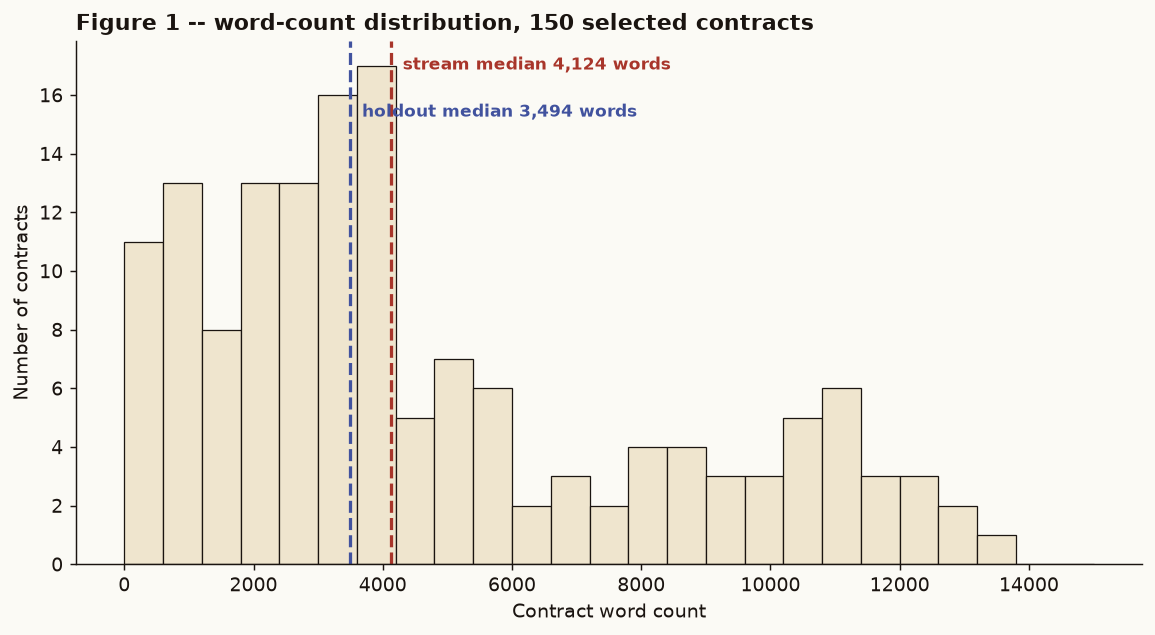

In [4]:
# --- Figure 1: word-count distribution of the 150 selected contracts ---
stream_words = selection_df.loc[selection_df["split"] == "stream", "word_count"]
holdout_words = selection_df.loc[selection_df["split"] == "holdout", "word_count"]
stream_median = stream_words.median()
holdout_median = holdout_words.median()

fig, ax = plt.subplots(figsize=(9, 5))
bin_edges = np.linspace(0, sel["max_words"], 26)
ax.hist(selection_df["word_count"], bins=bin_edges, color=BEIGE, edgecolor=INK,
        linewidth=0.7)

ax.axvline(stream_median, color=WINE, linewidth=1.8, linestyle="--")
ax.axvline(holdout_median, color=INDIGO, linewidth=1.8, linestyle="--")
y_top = ax.get_ylim()[1]
ax.text(stream_median, y_top * 0.97, f"  stream median {stream_median:,.0f} words",
        color=WINE, ha="left", va="top", fontsize=9.5, fontweight="bold")
ax.text(holdout_median, y_top * 0.88, f"  holdout median {holdout_median:,.0f} words",
        color=INDIGO, ha="left", va="top", fontsize=9.5, fontweight="bold")

ax.set_xlabel("Contract word count")
ax.set_ylabel("Number of contracts")
ax.set_title(f"Figure 1 -- word-count distribution, {len(selection_df)} selected contracts",
             loc="left", fontsize=12, fontweight="bold")
style_axis(ax)
fig.tight_layout()
plt.show()


## 2. The stream


In [5]:
n_batches = len(stream_events["batches"])
read_cap = extract_agent_log["read_cap"]
total_reads_val = evaluation["costs"]["total_reads"]
retries_total = extract_agent_log["retries_total"]

display(Markdown(
    f"The stream ran as **{n_batches} sequential batches**, key-blind "
    f"end to end -- no mid-stream accuracy checks, briefs frozen before the "
    f"first batch ran. It used **{total_reads_val}** reads in total "
    f"({extract_agent_log['reads_total']} contracts + {retries_total} "
    f"retries) against a hard cap of **{read_cap}**, leaving "
    f"{read_cap - total_reads_val} reads of headroom never spent. Batch "
    f"sizes: {[b['reads'] for b in extract_agent_log['batches']]}."
))


The stream ran as **8 sequential batches**, key-blind end to end -- no mid-stream accuracy checks, briefs frozen before the first batch ran. It used **52** reads in total (50 contracts + 2 retries) against a hard cap of **60**, leaving 8 reads of headroom never spent. Batch sizes: [6, 6, 6, 6, 6, 6, 7, 7].

### Figure 2 -- scope narrowing

Per batch, the mean number of categories still asked of the model per
contract read, against the full scope of all 12 categories. Gold markers
are the batches at which a matcher went active and started narrowing scope
(category initials labelled); wine markers are the batches at which a
matcher was demoted back out (initials labelled). Read from
`stream_events.json`'s `batches[*].scope_sizes` and `matcher_lifecycle`.


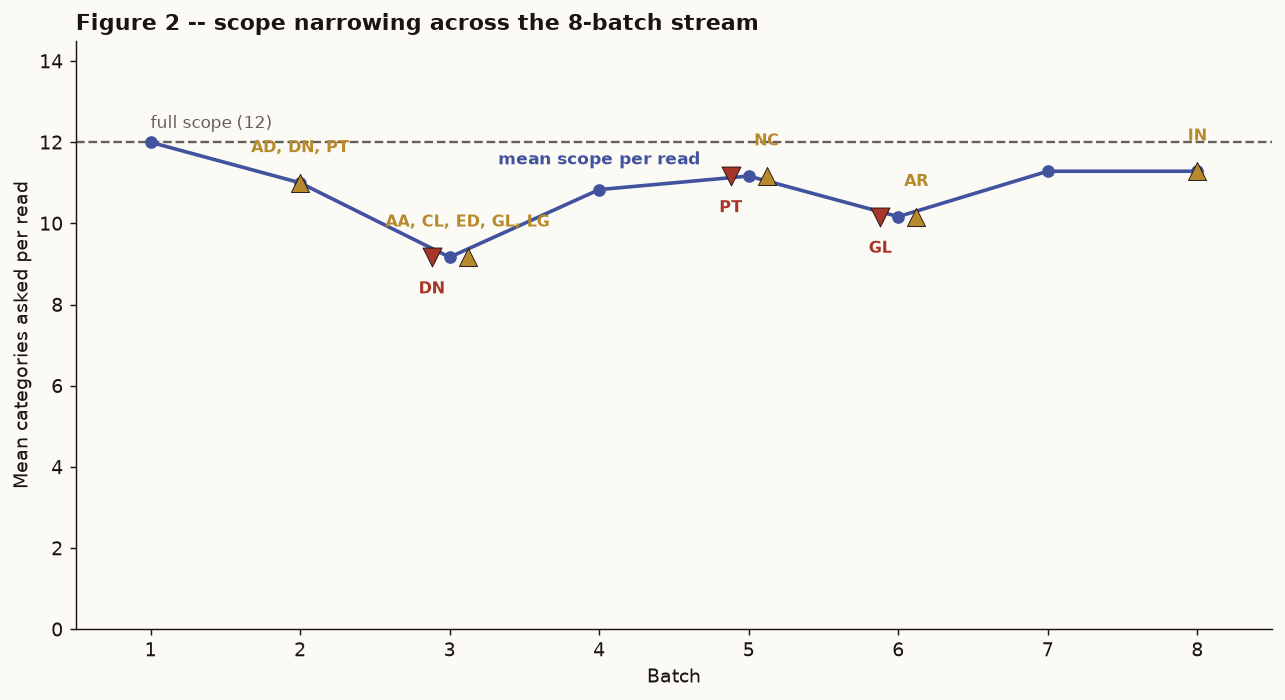

In [6]:
CATEGORY_INITIALS = {
    "Agreement Date": "AD", "Anti-Assignment": "AA", "Audit Rights": "AR",
    "Cap on Liability": "CL", "Document Name": "DN", "Expiration Date": "ED",
    "Governing Law": "GL", "IP Ownership Assignment": "IP", "Insurance": "IN",
    "License Grant": "LG", "Non-Compete": "NC", "Parties": "PT",
}

batch_numbers = [b["batch"] for b in stream_events["batches"]]
mean_scope = [np.mean(list(b["scope_sizes"].values())) for b in stream_events["batches"]]
mean_scope_by_batch = dict(zip(batch_numbers, mean_scope))

lifecycle = stream_events["matcher_lifecycle"]

# Group category initials by the batch each event happened at.
births_by_batch, demotions_by_batch = {}, {}
for category, info in lifecycle.items():
    if info["active_from_batch"] is not None:
        births_by_batch.setdefault(info["active_from_batch"], []).append(
            CATEGORY_INITIALS[category]
        )
    if info["demoted_at_batch"] is not None:
        demotions_by_batch.setdefault(info["demoted_at_batch"], []).append(
            CATEGORY_INITIALS[category]
        )

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axhline(12, color=GREY, linestyle="--", linewidth=1.3)
ax.text(batch_numbers[0], 12.25, "full scope (12)", color=GREY, va="bottom",
        ha="left", fontsize=9.5)

ax.plot(batch_numbers, mean_scope, color=INDIGO, marker="o", linewidth=2, zorder=3)
# A clean batch (no birth/demotion event) carries the line's direct label,
# clear of every marker annotation below.
clean_batches = [b for b in batch_numbers if b not in births_by_batch and b not in demotions_by_batch]
label_batch = clean_batches[len(clean_batches) // 2] if clean_batches else batch_numbers[-1]
ax.annotate("mean scope per read", xy=(label_batch, mean_scope_by_batch[label_batch]),
            xytext=(0, 14), textcoords="offset points", ha="center", color=INDIGO,
            fontsize=9.5, fontweight="bold")

# Births and demotions sometimes land on the same batch (e.g. one category
# demoted the same batch five others are born) -- nudge each marker
# horizontally so overlapping events stay visually distinct.
for batch, initials in sorted(births_by_batch.items()):
    y = mean_scope_by_batch[batch]
    x = batch + (0.12 if batch in demotions_by_batch else 0)
    ax.scatter([x], [y], marker="^", s=100, color=GOLD, zorder=4,
               edgecolor=INK, linewidth=0.5)
    ax.annotate(", ".join(sorted(initials)), xy=(x, y), xytext=(0, 17),
                textcoords="offset points", ha="center", color=GOLD,
                fontsize=9, fontweight="bold")

for batch, initials in sorted(demotions_by_batch.items()):
    y = mean_scope_by_batch[batch]
    x = batch - (0.12 if batch in births_by_batch else 0)
    ax.scatter([x], [y], marker="v", s=110, color=WINE, zorder=4,
               edgecolor=INK, linewidth=0.5)
    ax.annotate(", ".join(sorted(initials)), xy=(x, y), xytext=(0, -20),
                textcoords="offset points", ha="center", color=WINE,
                fontsize=9, fontweight="bold")

ax.set_xlabel("Batch")
ax.set_ylabel("Mean categories asked per read")
ax.set_xticks(batch_numbers)
ax.set_ylim(0, 14.5)
ax.set_xlim(batch_numbers[0] - 0.5, batch_numbers[-1] + 0.5)
ax.set_title("Figure 2 -- scope narrowing across the 8-batch stream",
             loc="left", fontsize=12, fontweight="bold")
style_axis(ax)
fig.tight_layout()
plt.show()


### Matcher lifecycle

One row per category: when its matcher was commissioned, the gate result,
the batch it went active (if it did), the batch and reason it was demoted
or failed (if it was), and where it ended up. Gate order is static checks
-> self-test over the induction set -> replay regression against every
later stream contract (`code/regression_gate.py`); the gate result below is
derived from each category's own event history, not retyped.


In [7]:
import re


def gate_result_from_history(history):
    failed = [h for h in history if h["event"] == "failed"]
    active = [h for h in history if h["event"] == "active"]
    if not failed:
        return "PASS"
    if active and active[-1]["batch"] >= failed[-1]["batch"]:
        return "FAIL then PASS"
    return "FAIL"


def summarize_reason(info):
    '''Derive a short, human-readable note from the category's own history
    -- never a hand-typed narrative. Demotions quote the shadow-flagged
    contract (extracted from the recorded reason string); gate failures
    quote the recorded failure detail verbatim.'''
    if info["status"] == "demoted" and info["demotion_reason"]:
        match = re.match(r"shadow regression disagreement on ([^:]+):",
                          info["demotion_reason"])
        contract = match.group(1) if match else "a stream contract"
        return f"shadow disagreement on {contract} (detail in report.md)"
    if info["status"] == "failed":
        failed_events = [h for h in info["history"] if h["event"] == "failed"]
        return failed_events[-1]["detail"] if failed_events else "gate failed"
    return "—"


rows = []
for category, info in lifecycle.items():
    rows.append({
        "category": category,
        "commissioned at batch": info["commissioned_at_batch"],
        "gate result": gate_result_from_history(info["history"]),
        "active from": info["active_from_batch"] if info["active_from_batch"] else "—",
        "demoted at": info["demoted_at_batch"] if info["demoted_at_batch"] else "—",
        "reason (demotion / gate failure)": summarize_reason(info),
        "final status": info["status"],
        "trust": info["trust"],
    })

lifecycle_df = pd.DataFrame(rows).sort_values(
    ["commissioned at batch", "category"]
).reset_index(drop=True)


def _row_style(row):
    color = {"active": BEIGE, "demoted": "#F3E1DE", "failed": "#E7E4E1"}.get(
        row["final status"], BG
    )
    return [f"background-color: {color}; color: {INK}"] * len(row)


display(lifecycle_df.style.apply(_row_style, axis=1).hide(axis="index"))


category,commissioned at batch,gate result,active from,demoted at,reason (demotion / gate failure),final status,trust
Agreement Date,1,PASS,2,—,—,active,one-sided
Document Name,1,PASS,2,3,shadow disagreement on CardlyticsInc_20180112_S-1_EX-10.16_11002987_EX-10.16_Maintenance Agreement4.txt (detail in report.md),demoted,one-sided
Parties,1,FAIL then PASS,2,5,shadow disagreement on REGANHOLDINGCORP_03_31_2008-EX-10-LICENSE AND HOSTING AGREEMENT.txt (detail in report.md),demoted,one-sided
Anti-Assignment,2,PASS,3,—,—,active,one-sided
Cap on Liability,2,PASS,3,—,—,active,one-sided
Expiration Date,2,PASS,3,—,—,active,one-sided
Governing Law,2,PASS,3,6,shadow disagreement on WestPharmaceuticalServicesInc_20200116_8-K_EX-10.1_11947529_EX-10.1_Supply Agreement.txt (detail in report.md),demoted,one-sided
License Grant,2,PASS,3,—,—,active,one-sided
IP Ownership Assignment,4,FAIL,—,—,replay failed: 1 disagreement(s),failed,one-sided
Non-Compete,4,PASS,5,—,—,active,one-sided


## 3. The gate and the shadows

The activation gate is deterministic: static source checks, then a
self-test over the matcher's own induction examples, then a replay against
every stream contract the model went on to read for that category. A
matcher that fails any stage never goes live; a matcher that passes is then
watched in production, one shadow comparison at a time.


In [8]:
gate_files = sorted((RUNS_DIR / "gate_results").glob("*.json"))
gate_results = [load_json(p) for p in gate_files]
gate_failures = [g for g in gate_results if not g["pass"]]

shadow_entries = shadow_answers["entries"]
shadow_agree = sum(1 for e in shadow_entries if e["agree"])
shadow_disagree = sum(1 for e in shadow_entries if not e["agree"])

display(Markdown(
    f"**{len(gate_results)}** matchers were put through the gate; "
    f"**{len(gate_failures)}** failed outright "
    f"({', '.join(g['category'] for g in gate_failures)}, frozen and never "
    f"recommissioned for a logic reason -- as opposed to Parties, whose "
    f"first commission failed on a source-level protocol check and was "
    f"fixed and recommissioned, per the lifecycle table above). Of the "
    f"matchers that went live, **{len(shadow_entries)}** shadow comparisons "
    f"ran in production (one active matcher's answer double-checked "
    f"against a live model read, same contract, same category): "
    f"**{shadow_agree}** agreed, **{shadow_disagree}** disagreed -- and "
    f"every disagreement demoted its matcher on the spot, permanently."
))

# --- Hand-adjudicated constant -- NOT machine-derived. -------------------
# A human read every one of the 80 evaluation_worksheet.md disagreement
# rows by hand (evaluation.json's worksheet_counts.mismatches == 80). That
# reading, not any JSON in data/runs/, is the source of this count: four
# matcher errors on stream contracts the shadow sampling never happened to
# sample. Source: data/runs/report.md, "What the shadow system did and did
# not catch." This is the first of the two constants this notebook is
# allowed to hardcode.
UNCAUGHT_MATCHER_ERRORS_FOUND_AT_ADJUDICATION = 4

display(Markdown(
    "**Hand-adjudicated constant (not machine-derived):** reading the full "
    f"disagreement worksheet by hand later found "
    f"**{UNCAUGHT_MATCHER_ERRORS_FOUND_AT_ADJUDICATION} further matcher "
    "errors** on stream contracts the shadow system never happened to "
    "sample -- one shadow comparison per category per batch is a spot "
    "check, not a proof, and this is the direct evidence of that limit."
))


**12** matchers were put through the gate; **1** failed outright (IP Ownership Assignment, frozen and never recommissioned for a logic reason -- as opposed to Parties, whose first commission failed on a source-level protocol check and was fixed and recommissioned, per the lifecycle table above). Of the matchers that went live, **33** shadow comparisons ran in production (one active matcher's answer double-checked against a live model read, same contract, same category): **30** agreed, **3** disagreed -- and every disagreement demoted its matcher on the spot, permanently.

**Hand-adjudicated constant (not machine-derived):** reading the full disagreement worksheet by hand later found **4 further matcher errors** on stream contracts the shadow system never happened to sample -- one shadow comparison per category per batch is a spot check, not a proof, and this is the direct evidence of that limit.

### Figure 3 -- predicted vs actual

The pre-registered prediction against what actually happened, per
category, read from `evaluation.json`'s `predicted_vs_actual` table (order
as recorded there). A = automatable (gold), P = partially automatable
(indigo), R = model-resident (wine); a check marks a match.


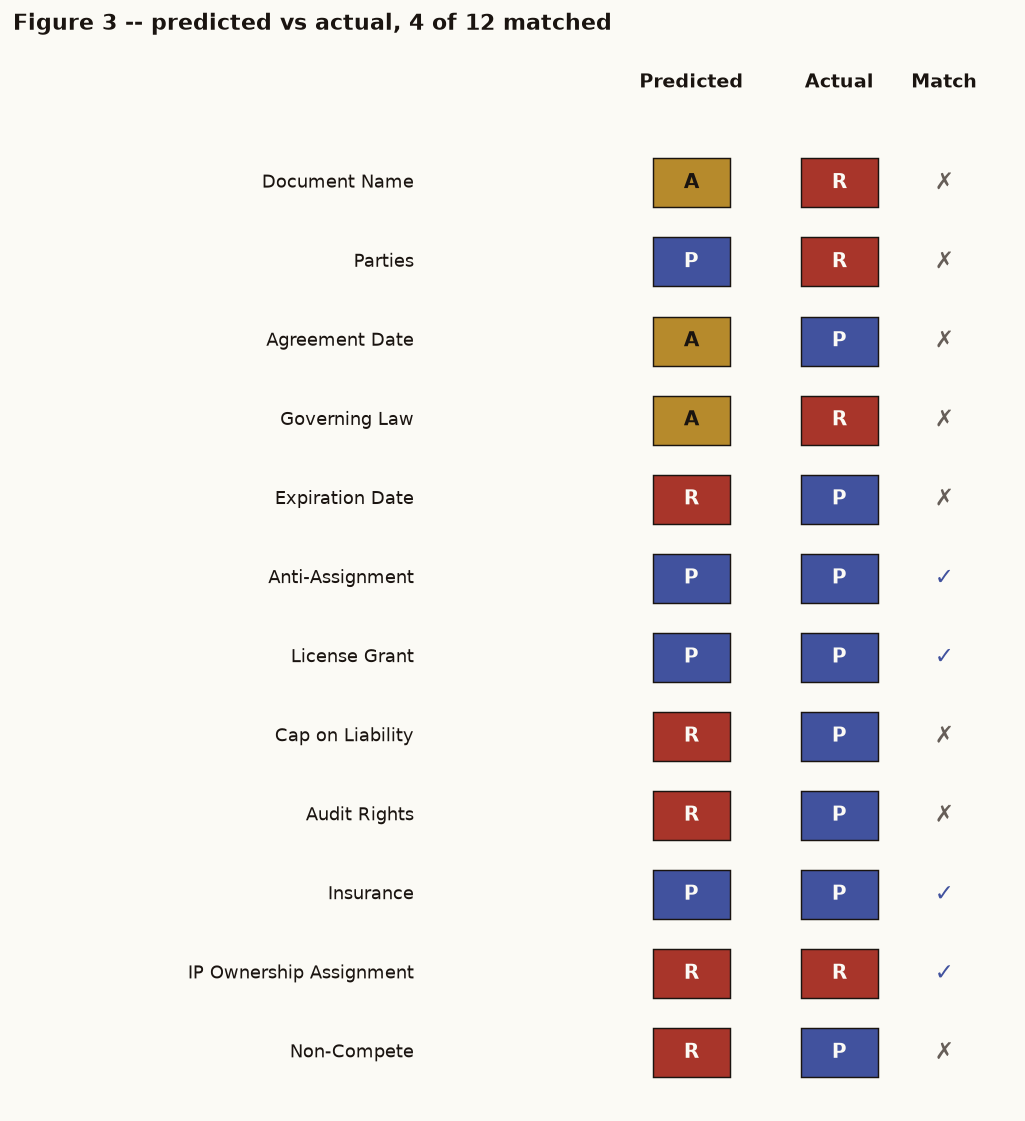

In [9]:
CLASS_COLOR = {"A": GOLD, "P": INDIGO, "R": WINE}
pva = evaluation["predicted_vs_actual"]
n_rows = len(pva)

fig, ax = plt.subplots(figsize=(8, 0.62 * n_rows + 1.3))
box_w, box_h = 0.62, 0.62
col_x = {"predicted": 2.1, "actual": 3.3}

for i, row in enumerate(pva):
    y = n_rows - i - 1
    ax.text(-0.15, y, row["category"], ha="right", va="center", fontsize=10)
    for col, x in col_x.items():
        letter = row[col]
        color = CLASS_COLOR[letter]
        rect = plt.Rectangle((x - box_w / 2, y - box_h / 2), box_w, box_h,
                              facecolor=color, edgecolor=INK, linewidth=0.8)
        ax.add_patch(rect)
        text_color = BG if color in (INDIGO, WINE) else INK
        ax.text(x, y, letter, ha="center", va="center", color=text_color,
                fontsize=11, fontweight="bold")
    mark = "✓" if row["match"] else "✗"
    mark_color = INDIGO if row["match"] else GREY
    ax.text(4.15, y, mark, ha="center", va="center", color=mark_color,
            fontsize=13, fontweight="bold")

ax.text(col_x["predicted"], n_rows + 0.15, "Predicted", ha="center",
        va="bottom", fontsize=10.5, fontweight="bold")
ax.text(col_x["actual"], n_rows + 0.15, "Actual", ha="center", va="bottom",
        fontsize=10.5, fontweight="bold")
ax.text(4.15, n_rows + 0.15, "Match", ha="center", va="bottom", fontsize=10.5,
        fontweight="bold")

n_matches = sum(1 for row in pva if row["match"])
ax.set_title(f"Figure 3 -- predicted vs actual, {n_matches} of {n_rows} matched",
             loc="left", fontsize=12, fontweight="bold")
ax.set_xlim(-3.4, 4.7)
ax.set_ylim(-0.7, n_rows + 0.8)
ax.axis("off")
fig.tight_layout()
plt.show()


## 4. Coverage & equivalence

Every active matcher answers only the instances it trusts and returns
`NoMatch` on the rest, which the model then covers as fallback. That
selection effect cuts both ways in the numbers below: a matcher's holdout
accuracy is measured only over the subset it chose to answer, which is by
construction the easier subset within its category. The honest claim from
this section is **"equivalent-or-better on the instances a matcher
accepts"** -- not "better than the model" across the board. The categories
below are the ones with an active matcher only; demoted and failed
categories carry no holdout figures, because their matchers never ran on
held-out data at all.


### Figure 4 -- holdout coverage vs accuracy

Horizontal bars are holdout coverage per active category (share of the
holdout set the matcher chose to answer, rather than returning `NoMatch`);
accuracy against the key and the holdout n are printed at the bar end.
Audit Rights answered nothing at all; Expiration Date is flagged wine as
the one active matcher whose covered answers were wrong a meaningful share
of the time.


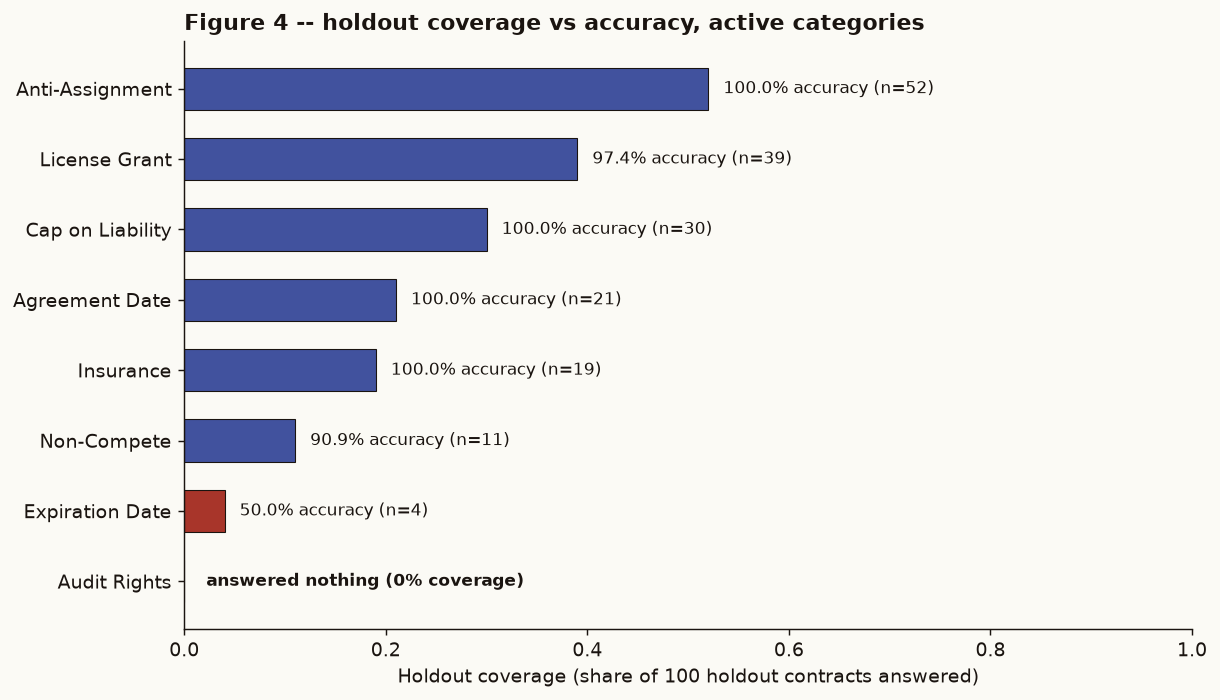

In [10]:
equiv = sorted(evaluation["equivalence_table"], key=lambda r: r["holdout_coverage"])
categories_eq = [r["category"] for r in equiv]
coverages = [r["holdout_coverage"] for r in equiv]

WINE_FLAG_THRESHOLD = 0.75  # flag an active matcher's holdout accuracy in
                            # wine when it falls meaningfully short of
                            # reliable -- a display rule, not a retyped
                            # result; whichever category trips it is read
                            # live from equiv below.
bar_colors = [
    WINE if (r["holdout_accuracy"] is not None and r["holdout_accuracy"] < WINE_FLAG_THRESHOLD)
    else INDIGO
    for r in equiv
]

fig, ax = plt.subplots(figsize=(9.5, 5.5))
y_pos = np.arange(len(categories_eq))
ax.barh(y_pos, coverages, color=bar_colors, edgecolor=INK, linewidth=0.6, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(categories_eq)
ax.set_xlabel(f"Holdout coverage (share of {evaluation['holdout_size']} "
              "holdout contracts answered)")
ax.set_xlim(0, 1.0)

for y, r in zip(y_pos, equiv):
    if r["holdout_n"] == 0:
        ax.text(0.01, y, "  answered nothing (0% coverage)", va="center",
                ha="left", color=INK, fontsize=9.5, fontweight="bold")
        continue
    acc_text = f"{r['holdout_accuracy']:.1%} accuracy (n={r['holdout_n']})"
    color = WINE if r["holdout_coverage"] < WINE_FLAG_THRESHOLD and bar_colors[y] == WINE else INK
    ax.text(r["holdout_coverage"] + 0.015, y, acc_text, va="center", ha="left",
             color=INK, fontsize=9.5)

ax.set_title("Figure 4 -- holdout coverage vs accuracy, active categories",
             loc="left", fontsize=12, fontweight="bold")
style_axis(ax)
fig.tight_layout()
plt.show()


## 5. Accuracy, as marked

Three path/split aggregates, recomputed here directly from
`evaluation.json`'s per-category scoring tables (never retyped from the
report). "Presence accuracy" scores yes/no categories and whether an
extraction category's presence call was right; "answer accuracy" additionally
scores the extracted value itself, over key-answerable rows only.


In [11]:
def aggregate_scoring(entries):
    presence_correct = sum(e["presence_correct"] for e in entries)
    presence_total = sum(e["presence_total"] for e in entries)
    answer_correct = sum(e["answer_correct"] for e in entries)
    answer_total = sum(e["answer_total"] for e in entries)
    return {
        "n": sum(e["n"] for e in entries),
        "presence_correct": presence_correct,
        "presence_total": presence_total,
        "presence_accuracy": presence_correct / presence_total if presence_total else None,
        "answer_correct": answer_correct,
        "answer_total": answer_total,
        "answer_accuracy": answer_correct / answer_total if answer_total else None,
    }


matcher_stream_entries = [v["matcher"] for v in evaluation["stream_scoring"].values()]
llm_stream_entries = [v["llm"] for v in evaluation["stream_scoring"].values()]
matcher_holdout_entries = list(evaluation["holdout_scoring"].values())

accuracy_rows = {
    "Matcher, stream": aggregate_scoring(matcher_stream_entries),
    "Model, stream": aggregate_scoring(llm_stream_entries),
    "Matcher, holdout": aggregate_scoring(matcher_holdout_entries),
}
accuracy_df = pd.DataFrame(accuracy_rows).T
accuracy_df["presence"] = accuracy_df.apply(
    lambda r: f"{int(r.presence_correct)}/{int(r.presence_total)} "
              f"({r.presence_accuracy:.1%})" if r.presence_accuracy is not None else "n/a",
    axis=1,
)
accuracy_df["answer"] = accuracy_df.apply(
    lambda r: f"{int(r.answer_correct)}/{int(r.answer_total)} "
              f"({r.answer_accuracy:.1%})" if r.answer_accuracy is not None else "n/a",
    axis=1,
)
display(accuracy_df[["n", "presence", "answer"]])

# Internal-consistency check: the three rows' n must sum to the same total
# already asserted in the live-asserts cell above (total_comparisons_marked),
# split the other way -- matcher-vs-llm, stream-vs-holdout instead of
# category-by-category.
assert accuracy_df["n"].sum() == total_comparisons_marked, (
    "path/split aggregate n does not reconcile with the category-level total"
)
print(f"\nReconciles: {int(accuracy_df['n'].sum())} total, matching the "
      f"{total_comparisons_marked} comparisons marked above.")


,n,presence,answer
"Matcher, stream",89.0,88/89 (98.9%),37/44 (84.1%)
"Model, stream",511.0,476/511 (93.2%),141/174 (81.0%)
"Matcher, holdout",176.0,173/176 (98.3%),22/23 (95.7%)



Reconciles: 776 total, matching the 776 comparisons marked above.


## 6. Presence-only rule

Pre-registered before any pipeline run: CUAD sometimes records a supporting
span for an extraction category but leaves the normalised answer blank --
almost entirely Expiration Date, where an answer requires computing a date
rather than quoting one. Comparing a pipeline's computed answer against a
blank key cell is not marking, so those rows score on presence only
(matched or not that the clause exists), are excluded from the
answer-accuracy denominator above, and are routed to the adjudication lane.


In [12]:
presence_only_stream = sum(
    v["llm"]["presence_only_count"] + v["matcher"]["presence_only_count"]
    for v in evaluation["stream_scoring"].values()
)
presence_only_holdout = sum(v["presence_only_count"] for v in evaluation["holdout_scoring"].values())
presence_only_total = presence_only_stream + presence_only_holdout

assert presence_only_total == evaluation["worksheet_counts"]["presence_only"], (
    "recomputed presence-only count does not match worksheet_counts"
)

display(Markdown(
    f"**{presence_only_total}** rows were scored presence-only in this run "
    f"({presence_only_stream} on the stream, {presence_only_holdout} on the "
    "holdout) -- consistent with `worksheet_counts.presence_only` in "
    "`evaluation.json`."
))


**12** rows were scored presence-only in this run (11 on the stream, 1 on the holdout) -- consistent with `worksheet_counts.presence_only` in `evaluation.json`.

## 7. The adjudication

Every disagreement between the pipeline and the key was read by hand: all
extraction/A-P-category mismatches plus a seeded sample of R-category
mismatches -- `evaluation.json`'s `worksheet_counts` records the full
accounting. Zero cases were "adjudicate-first" (both paths agreeing with
each other against the key) -- if that had happened even once it would have
been adjudicated regardless, as either our shared error or the most
interesting row in the whole case. The key itself was never edited;
everything below is read as-marked.


In [13]:
wc = evaluation["worksheet_counts"]
display(Markdown(
    f"**{wc['mismatches']}** mismatches were adjudicated in total (every "
    f"extraction/A-P mismatch, plus a seeded sample of "
    f"{wc['r_category_sample']} of {wc['r_category_mismatches_total']} "
    f"R-category mismatches). `adjudicate_first` = {wc['adjudicate_first']}: "
    "no case where both paths agreed with each other against the key."
))

# --- Hand-adjudicated constants -- NOT machine-derived. ------------------
# A human read all 80 disagreement rows in evaluation_worksheet.md and
# classified each by hand into one of five families. This classification
# exists nowhere in data/runs/*.json -- it is a judgement call recorded in
# data/runs/report.md ("The adjudication -- what the 80 disagreements
# actually were"), not a machine output. This is the second (and last) of
# the two constants this notebook is allowed to hardcode.
ADJUDICATION_FAMILIES = {
    "Key errors or arguable key errors": 15,
    "Genuinely ambiguous": 28,
    "Equivalent readings defeated by the pinned comparator": 19,
    "Pipeline (model) genuinely wrong": 8,
    "Pipeline (matcher) genuinely wrong": 10,
}
assert sum(ADJUDICATION_FAMILIES.values()) == wc["mismatches"], (
    "hand-adjudicated family counts do not sum to the recomputed mismatch total"
)

family_df = pd.DataFrame(
    {"rows (hand-adjudicated)": ADJUDICATION_FAMILIES,
     "share of mismatches": {k: v / wc["mismatches"] for k, v in ADJUDICATION_FAMILIES.items()}}
)
family_df["share of mismatches"] = family_df["share of mismatches"].map(lambda x: f"{x:.0%}")
display(family_df)

key_error_share_of_all_marked = ADJUDICATION_FAMILIES["Key errors or arguable key errors"] / total_comparisons_marked
display(Markdown(
    "The key-error share reads large among *disagreements* "
    f"({ADJUDICATION_FAMILIES['Key errors or arguable key errors']} / {wc['mismatches']} "
    f"= {ADJUDICATION_FAMILIES['Key errors or arguable key errors'] / wc['mismatches']:.0%}) "
    f"and small against *everything marked* "
    f"({ADJUDICATION_FAMILIES['Key errors or arguable key errors']} / {total_comparisons_marked} "
    f"≈ {key_error_share_of_all_marked:.1%}). Both framings are the same "
    "15 rows; neither is more honest than the other, and both are printed here "
    "together rather than choosing one."
))


**80** mismatches were adjudicated in total (every extraction/A-P mismatch, plus a seeded sample of 20 of 34 R-category mismatches). `adjudicate_first` = 0: no case where both paths agreed with each other against the key.

,rows (hand-adjudicated),share of mismatches
Key errors or arguable key errors,15,19%
Genuinely ambiguous,28,35%
Equivalent readings defeated by the pinned comparator,19,24%
Pipeline (model) genuinely wrong,8,10%
Pipeline (matcher) genuinely wrong,10,12%


The key-error share reads large among *disagreements* (15 / 80 = 19%) and small against *everything marked* (15 / 776 ≈ 1.9%). Both framings are the same 15 rows; neither is more honest than the other, and both are printed here together rather than choosing one.

## 8. N-threshold sensitivity ablation

The overseer commissions a matcher once a category has accumulated
`N_INDUCTION = 6` accepted positives from the model's stream reads
(`code/config.py`). What if that threshold had been set differently? This
section replays the actual stream, batch by batch, using only the model's
real accepted extractions (`data/runs/llm_extractions/`) and each
contract's real batch membership (`stream_events.json`) -- for every
category and every N from 3 to 10, it finds the batch at which the Nth
accepted positive would have landed.

This is **not** a full counterfactual: once the real N=6 threshold retired
a category early, the model mostly stopped being asked about it (bar
fallback reads when a matcher returned `NoMatch`), so a hypothetical higher
threshold's later columns are starved of the additional evidence that would
only have existed in a world where that threshold had applied from the
start. The N=6 column, precisely because it matches what actually ran, is
exact; N=4 and N=10 are read as a directional sensitivity check on the
pipeline's own path-dependent history, not as an independent simulation.


In [14]:
categories_all = sorted(evaluation["predictions"].keys())
N_RANGE = range(3, 11)

cumulative_positives = {c: 0 for c in categories_all}
eligibility_batch = {c: {} for c in categories_all}

for batch in stream_events["batches"]:
    batch_number = batch["batch"]
    for contract in batch["contracts"]:
        stem = contract[:-4] if contract.lower().endswith(".txt") else contract
        extraction_path = RUNS_DIR / "llm_extractions" / f"{stem}.json"
        if not extraction_path.exists():
            continue
        record = load_json(extraction_path)
        for category, entry in record.get("categories", {}).items():
            if entry.get("present"):
                cumulative_positives[category] += 1
    for category in categories_all:
        for n_threshold in N_RANGE:
            if n_threshold not in eligibility_batch[category] and cumulative_positives[category] >= n_threshold:
                eligibility_batch[category][n_threshold] = batch_number

ablation_matrix = pd.DataFrame(
    {n: {c: eligibility_batch[c].get(n) for c in categories_all} for n in N_RANGE}
)
ablation_matrix.index.name = "category"
display(ablation_matrix)

# Live regression check: the N=6 column must reproduce the actual
# commissioning batch on record for every category (this run's real
# induction threshold was 6).
for category in categories_all:
    computed = eligibility_batch[category].get(6)
    actual = lifecycle[category]["commissioned_at_batch"]
    assert computed == actual, (
        f"{category}: N=6 eligibility batch {computed} does not reproduce "
        f"the actual commissioned_at_batch {actual}"
    )
print("N=6 column reproduces every category's actual commissioning batch.")


,3,4,5,6,7,8,9,10
category,,,,,,,,
Agreement Date,1,1,1,1,2.0,2.0,2.0,2.0
Anti-Assignment,1,1,1,2,2.0,2.0,3.0,4.0
Audit Rights,3,4,4,5,5.0,5.0,5.0,6.0
Cap on Liability,2,2,2,2,4.0,4.0,5.0,5.0
Document Name,1,1,1,1,4.0,4.0,4.0,4.0
Expiration Date,1,1,1,2,2.0,2.0,2.0,2.0
Governing Law,1,1,1,2,2.0,2.0,2.0,2.0
IP Ownership Assignment,2,3,3,4,4.0,4.0,4.0,5.0
Insurance,6,7,7,7,NaN,NaN,NaN,NaN


N=6 column reproduces every category's actual commissioning batch.


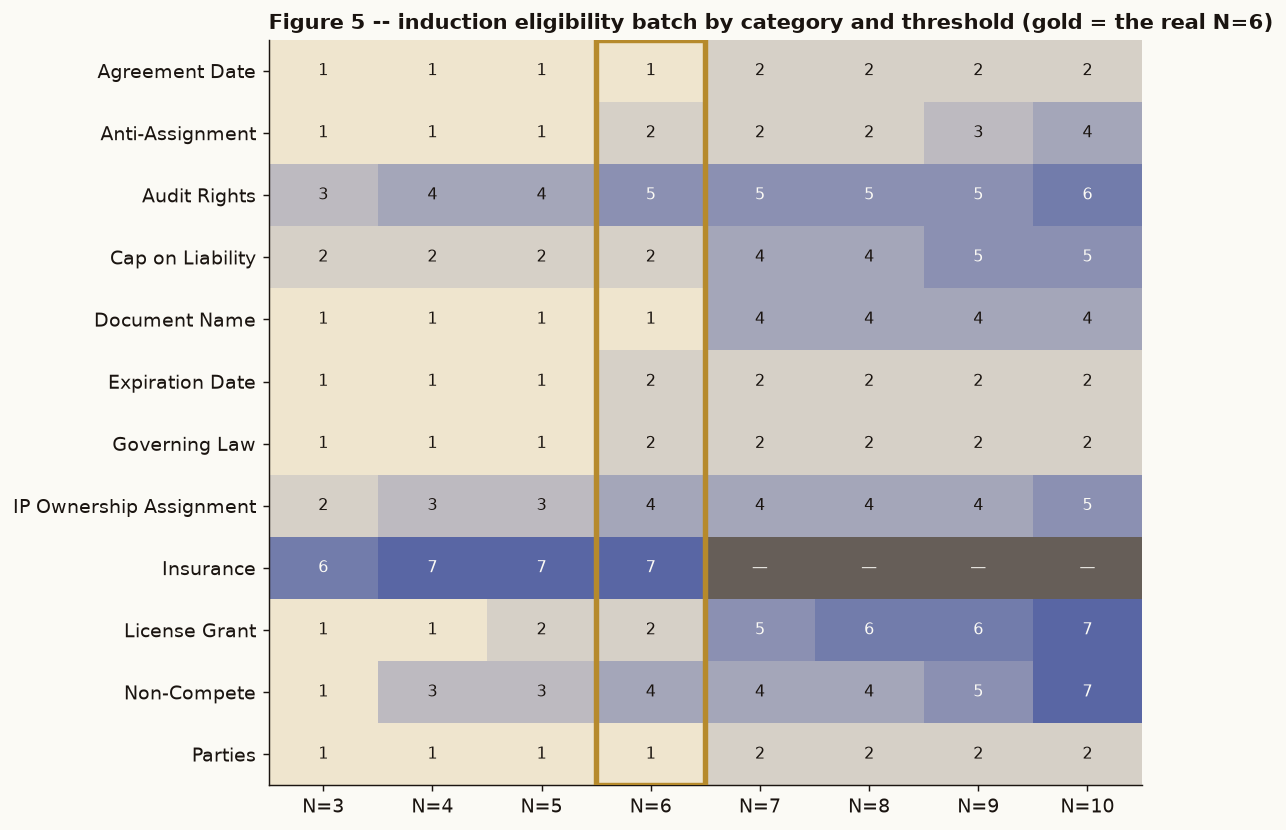

In [15]:
# --- Figure 5: eligibility batch by category x N, N=6 column outlined ---
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle

cmap = LinearSegmentedColormap.from_list("beige_indigo", [BEIGE, INDIGO])
max_batch = len(stream_events["batches"])

matrix_values = ablation_matrix.to_numpy(dtype=float)  # NaN where never reached
display_matrix = np.where(np.isnan(matrix_values), np.nan, matrix_values)

fig, ax = plt.subplots(figsize=(9, 6.5))
masked = np.ma.masked_invalid(display_matrix)
cmap.set_bad(color=GREY)
im = ax.imshow(masked, cmap=cmap, vmin=1, vmax=max_batch, aspect="auto")

for i, category in enumerate(ablation_matrix.index):
    for j, n_threshold in enumerate(ablation_matrix.columns):
        value = ablation_matrix.iloc[i, j]
        if pd.isna(value):
            ax.text(j, i, "—", ha="center", va="center", color=BG, fontsize=9)
            continue
        normalized = (value - 1) / (max_batch - 1)
        text_color = BG if normalized > 0.55 else INK
        ax.text(j, i, int(value), ha="center", va="center", color=text_color, fontsize=9)

n6_index = list(ablation_matrix.columns).index(6)
rect = Rectangle((n6_index - 0.5, -0.5), 1, len(ablation_matrix.index),
                  fill=False, edgecolor=GOLD, linewidth=3, zorder=5)
ax.add_patch(rect)

ax.set_xticks(range(len(ablation_matrix.columns)))
ax.set_xticklabels([f"N={n}" for n in ablation_matrix.columns])
ax.set_yticks(range(len(ablation_matrix.index)))
ax.set_yticklabels(ablation_matrix.index)
ax.set_title("Figure 5 -- induction eligibility batch by category and threshold "
             "(gold = the real N=6)", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()


In [16]:
n4_earlier = {
    c: (eligibility_batch[c].get(4), eligibility_batch[c].get(6))
    for c in categories_all
    if eligibility_batch[c].get(4) is not None
    and eligibility_batch[c].get(6) is not None
    and eligibility_batch[c].get(4) < eligibility_batch[c].get(6)
}
n10_never_reached = [c for c in categories_all if eligibility_batch[c].get(10) is None]

demoted_categories = [c for c, info in lifecycle.items() if info["status"] == "demoted"]
earliest_commission_batch = min(
    info["commissioned_at_batch"] for info in lifecycle.values()
    if info["commissioned_at_batch"] is not None
)
demoted_at_earliest = [
    c for c in demoted_categories
    if lifecycle[c]["commissioned_at_batch"] == earliest_commission_batch
]

n4_lines = "; ".join(
    f"{c} (batch {a4} vs batch {a6} at the real N=6)" for c, (a4, a6) in sorted(n4_earlier.items())
)

display(Markdown(
    f"**At N=4**, {len(n4_earlier)} of the 12 categories would have crossed "
    f"the induction threshold at least one batch earlier than they actually "
    f"did: {n4_lines}. Of the categories that already committed at the "
    f"earliest possible batch (batch {earliest_commission_batch}) under the "
    f"real N=6, {' and '.join(demoted_at_earliest) if demoted_at_earliest else 'none'} "
    f"{'were' if len(demoted_at_earliest) != 1 else 'was'} later demoted for a "
    "genuine matcher defect -- a stricter floor of 4 accepted positives does "
    "not fix that, it only means more categories would commission on "
    "evidence at least as thin.\n\n"
    f"**At N=10**, {', '.join(n10_never_reached)} never reaches the "
    f"threshold inside the {evaluation['stream_size']}-contract stream at "
    "all -- it would simply never have been commissioned. Its real "
    f"commissioning, at batch {lifecycle[n10_never_reached[0]]['commissioned_at_batch']} "
    f"of {len(stream_events['batches'])}, was already the last of the "
    f"{len(categories_all)} induction events in this run, so this is the "
    "threshold at which the stream runs out of runway before the category "
    "does."
))


**At N=4**, 7 of the 12 categories would have crossed the induction threshold at least one batch earlier than they actually did: Anti-Assignment (batch 1 vs batch 2 at the real N=6); Audit Rights (batch 4 vs batch 5 at the real N=6); Expiration Date (batch 1 vs batch 2 at the real N=6); Governing Law (batch 1 vs batch 2 at the real N=6); IP Ownership Assignment (batch 3 vs batch 4 at the real N=6); License Grant (batch 1 vs batch 2 at the real N=6); Non-Compete (batch 3 vs batch 4 at the real N=6). Of the categories that already committed at the earliest possible batch (batch 1) under the real N=6, Document Name and Parties were later demoted for a genuine matcher defect -- a stricter floor of 4 accepted positives does not fix that, it only means more categories would commission on evidence at least as thin.

**At N=10**, Insurance never reaches the threshold inside the 50-contract stream at all -- it would simply never have been commissioned. Its real commissioning, at batch 7 of 8, was already the last of the 12 induction events in this run, so this is the threshold at which the stream runs out of runway before the category does.

## 9. Costs

Method B: Claude Code subagents, zero marginal spend to Hapax, so every
dollar figure below is derived from measured subagent token counts x
published per-token prices -- an estimate, labelled as such throughout, not
a metered bill.


In [17]:
costs = evaluation["costs"]


def flatten_bands(bands):
    '''Each cost figure is nested pricing-tier -> band -> USD; flatten to
    one row of (tier, band) columns so it fits a plain table.'''
    return {
        f"{tier}: {band.replace('_usd', '')}": value
        for tier, values in bands.items() for band, value in values.items()
    }


cost_rows = {
    "Run, extraction only": flatten_bands(costs["run_cost_bands_extraction_only"]),
    "Run, total incl. overseer": flatten_bands(costs["run_cost_bands_total"]),
    f"Holdout counterfactual (model reads all {evaluation['holdout_size']})":
        flatten_bands(costs["holdout_counterfactual_cost_bands"]),
}
column_order = [
    "introductory: lower", "introductory: central", "introductory: upper",
    "list: lower", "list: central", "list: upper",
]
cost_table = pd.DataFrame(cost_rows).T[column_order]
cost_table = cost_table.map(lambda v: f"${v:,.2f}")
print("All figures below are estimates (Method B: published per-token prices x measured subagent tokens).")
display(cost_table)

batch_7 = next(b for b in extract_agent_log["batches"] if b["batch"] == 7)
unmeasured = batch_7["unmeasured_segment"]
unmeasured_lo, unmeasured_hi = unmeasured["token_estimate_range"]

display(Markdown(
    f"Measured subagent tokens: **{costs['total_measured_subagent_tokens']:,}** "
    f"total ({costs['extraction_tokens_measured']:,} extraction + "
    f"{costs['overseer_tokens_measured']:,} overseer), excluding batch 7's "
    "pre-drop segment lost to a connection error (estimated separately, "
    f"{unmeasured_lo/1000:.0f}k-{unmeasured_hi/1000:.0f}k tokens, central "
    f"{unmeasured['token_estimate_central']/1000:.0f}k). Mean tokens per "
    f"stream read: **{costs['mean_tokens_per_read']:,.0f}** (estimate; "
    "extraction tokens only). The matcher path answered its "
    f"{sum(1 for r in evaluation['equivalence_table'])} active categories' "
    f"holdout share at **{costs['matcher_path_tokens']} marginal tokens** "
    "-- exact, not an estimate, because deterministic code has no token "
    "cost at all -- against an estimated "
    f"${costs['holdout_counterfactual_cost_bands']['introductory']['central_usd']:,.2f} "
    "(introductory pricing, central estimate) had the model read that same "
    f"{evaluation['holdout_size']}-contract holdout instead.\n\n"
    "**Not a crossover story.** Input tokens (reading the contract) dominate "
    "a read's cost, so scope narrowing mainly saves output work within the "
    "stream itself. The saving this case demonstrates is the *holdout year*: "
    "A/P categories answered by code that costs nothing, on twice the "
    "stream's volume, while the model is priced only for the R residue -- "
    "counterfactually, since the budget never actually runs it. No 03-style "
    "crossover curve is claimed here."
))


All figures below are estimates (Method B: published per-token prices x measured subagent tokens).


,introductory: lower,introductory: central,introductory: upper,list: lower,list: central,list: upper
"Run, extraction only",$3.39,$5.43,$16.96,$5.09,$8.14,$25.45
"Run, total incl. overseer",$6.82,$10.92,$34.12,$10.24,$16.38,$51.18
Holdout counterfactual (model reads all 100),$6.52,$10.44,$32.62,$9.79,$15.66,$48.94


Measured subagent tokens: **3,412,095** total (1,696,432 extraction + 1,651,185 overseer), excluding batch 7's pre-drop segment lost to a connection error (estimated separately, 100k-200k tokens, central 150k). Mean tokens per stream read: **32,624** (estimate; extraction tokens only). The matcher path answered its 8 active categories' holdout share at **0 marginal tokens** -- exact, not an estimate, because deterministic code has no token cost at all -- against an estimated $10.44 (introductory pricing, central estimate) had the model read that same 100-contract holdout instead.

**Not a crossover story.** Input tokens (reading the contract) dominate a read's cost, so scope narrowing mainly saves output work within the stream itself. The saving this case demonstrates is the *holdout year*: A/P categories answered by code that costs nothing, on twice the stream's volume, while the model is priced only for the R residue -- counterfactually, since the budget never actually runs it. No 03-style crossover curve is claimed here.

## 10. Limitations

- **Shadow sampling density.** One shadow comparison per category per
  batch is a spot check, not a proof -- the adjudication found matcher
  errors on stream contracts the shadow system never happened to sample
  (Section 3).
- **One-run non-determinism.** Every LLM output here is a session
  artefact from a single run of Sonnet subagents; nothing in this pipeline
  is re-run to average out sampling variance, and re-running it would
  produce different individual answers (though, per the batch-by-batch
  design, the same overall dynamics).
- **The comparator's Parties strictness.** Parties disagreements are
  disproportionately "equivalent readings defeated by the pinned
  comparator" (Section 7) -- the key packs collective parentheticals and
  role definitions into its answer strings in ways a token-set comparison
  cannot always survive. The comparator was pre-registered and stands;
  those rows are reported as what they are, not silently reclassified.
- **CUAD near-duplicates.** The corpus contains the same underlying filing
  entered under more than one filename with different byte content, so
  checksum-based deduplication correctly treats them as distinct and both
  can appear in the same stream.
- **Batch 7's unmeasured segment.** An API connection dropped mid-batch;
  the pre-drop token usage is lost and appears only as an estimate range in
  `extract_agent_log.json`, not a measured figure.


## Closing

Unlike the rest of the Hapax case-study portfolio, this corpus and its
answer key are real, not synthetic -- Case 4 is the one project in the
six-case portfolio where the marking authority predates the pipeline
entirely and was written by people who had never heard of Hapax. Wrong
predictions and matcher failures stay in print for exactly that reason.

**Attribution.** Corpus and annotations: CUAD v1 -- Hendrycks, D., Burns, C.,
Chen, A., & Ball, S. (2021). *CUAD: An Expert-Annotated NLP Dataset for
Legal Contract Review*. NeurIPS 2021 Datasets and Benchmarks Track.
arXiv:2103.06268. Dataset (c) The Atticus Project, Inc., licensed CC BY 4.0
(<https://creativecommons.org/licenses/by/4.0/>); this project's derived
files adapt `master_clauses.csv` under the same licence.

**Not legal advice.** Nothing in this notebook, or in the pipeline it
reports on, is a legal opinion. It processes documents and reports what it
found against a published answer key -- it does not practise law.
